In [1]:
%%capture
!pip install insightface opencv-python
!pip install onnxruntime-gpu
!pip install numpy deepface tenseal==0.3.16 tqdm lightphe chefboost

In [2]:
%%capture
import cv2
from insightface.app import FaceAnalysis
from skimage import transform as trans
from PIL import Image


# built-in dependencies
import os
import time
from typing import List
import pickle
import base64
import warnings
warnings.filterwarnings('ignore')


# 3rd party dependencies
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_lfw_pairs
from deepface import DeepFace
import tenseal as ts
import random
import torch


# metrics calculation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)
from sklearn.metrics import roc_curve, auc

2026-04-17 08:40:10.704581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776415210.964024      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776415211.043338      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776415211.694841      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776415211.694878      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776415211.694880      16 computation_placer.cc:177] computation placer alr

## Config

In [3]:
def set_seed(seed: int = 42):
    # 1. Python
    random.seed(seed)

    # 2. Numpy
    np.random.seed(seed)

    # 3. PyTorch CPU
    torch.manual_seed(seed)

    # 4. PyTorch GPU
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 5. CuDNN (QUAN TRỌNG)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 6. Hash seed (Python internal)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed set to {seed}")
    
def print_config(model_name, dist_metric, conf):
    print("-------CONFIG-------")
    print("Model name: ", model_name)
    print("Distance metric: ", dist_metric)
    print("Configure: ", conf)
    print("--------------------")

In [4]:
detector_backend = "mtcnn"
model_name = "Facenet512" # Set to "Facenet", "Facenet512" or "VGG-Face" #TODO: Change this
distance_metric = "cosine" # Set to euclidean, cosine #TODO: Change this

In [5]:
# tenseal cryptosystem configurations - these are all offering 128-bit security
configs = [
    (8192, [60, 40, 40, 60], 40),
    (16384, [31, 60, 60, 60, 60, 60, 60, 31], 60),
]

# set your crytosystem's configuration here
cs_config = configs[1] #TODO: change this

In [6]:
set_seed(42)

Seed set to 42


In [7]:
print_config(model_name, distance_metric, cs_config)

-------CONFIG-------
Model name:  Facenet512
Distance metric:  cosine
Configure:  (16384, [31, 60, 60, 60, 60, 60, 60, 31], 60)
--------------------


In [8]:
config = {
    "Facenet512": {
        "euclidean": 24.35,
        # "cosine": 0.026798495128309553,
        # "cosine": 0.02232566879533769,
        "cosine": 0.028744931705153496,
        
        
    },
    "Facenet": {
        "euclidean": 12.28,
        "cosine": 0.02431508799003538,
    },
    "VGG-Face": {
        "euclidean": 1.2066928963135033,
        # Best for euclidean 1.2066928963135033
        # "cosine": 0.663973458216446,
        "cosine": 0.7350410163764862,
        #best for cosine: 0.7350410163764862
    }
}


In [9]:
threshold = config[model_name][distance_metric]
threshold

0.028744931705153496

# Detect + Align

In [10]:
%%capture
app = FaceAnalysis(
    name='buffalo_l',   
    allowed_modules=['detection', 'landmark_2d_106'],
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,            # GPU (nếu crash thì đổi -1)
    det_size=(320, 320)  
)

In [11]:
src = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041]
], dtype=np.float32)

src = src * 2

def align_face(img, kps, size=224):
    tform = trans.SimilarityTransform()
    tform.estimate(kps, src)

    M = tform.params[0:2, :]
    
    aligned = cv2.warpAffine(img, M, (size, size))
    return aligned

In [12]:
def resize_img(img):
    h, w = img.shape[:2]
    # scale = 640 / max(h, w)
    # img = cv2.resize(img, (int(w*scale), int(h*scale)))
    return img
def show_img(img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()


def detect_and_align(img_path):
    img = cv2.imread(img_path)
    # print(img.shape)
    # img = resize_img(img)
    faces = app.get(img)
    # print("Face", faces)
    # plt.imshow(img)

    res = []
    for face in faces:
        bbox = face.bbox.astype(int)
        kps = face.kps.astype(int)  # 5 landmarks
        aligned_face = align_face(img, face.kps)
        # show_img(aligned_face)
        # print(aligned_face.shape)

        aligned_face_rgb = cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)
        res.append(aligned_face_rgb)
    # print(len(res))
    if(len(res) == 0):
        return img
    return res[0]

In [13]:
test_img_path = "/kaggle/input/datasets/hereisburak/pins-face-recognition/105_classes_pins_dataset/pins_Adriana Lima/Adriana Lima101_3.jpg"

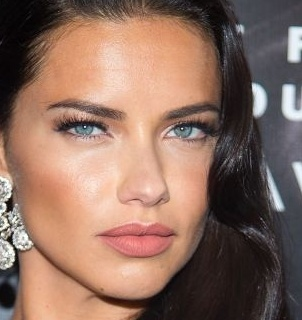

In [14]:
Image.open(test_img_path)

In [15]:
image = detect_and_align(test_img_path)

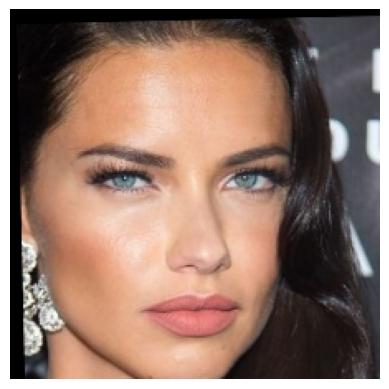

In [16]:
show_img(image)

# Data Preparation

In [17]:
target_path = "/kaggle/working/PFR/test"

In [18]:
# Đường dẫn tới thư mục chứa dữ liệu của bạn
DATA_DIR = '/kaggle/input/datasets/hereisburak/pins-face-recognition/105_classes_pins_dataset'

def create_face_pairs_dataframe(base_path, num_positive=500, num_negative=500):
    # 1. Thu thập tất cả đường dẫn ảnh và gom nhóm theo tên người (folder)
    celeb_images = {}
    
    for celeb_folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, celeb_folder)
        
        if os.path.isdir(folder_path):
            # Lấy tất cả các file có đuôi ảnh
            images = [os.path.join(folder_path, img) 
                      for img in os.listdir(folder_path) 
                      if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Chỉ lấy các folder có từ 2 ảnh trở lên (để tạo được cặp positive)
            if len(images) >= 2:
                celeb_images[celeb_folder] = images
                
    celebs = list(celeb_images.keys())
    
    pairs = []
    
    # 2. Tạo 500 cặp Positive (Cùng 1 người, label = 1)
    # Sử dụng set để tránh tạo ra các cặp trùng lặp y hệt nhau
    positive_set = set()
    while len(positive_set) < num_positive:
        # Chọn ngẫu nhiên 1 người
        celeb = random.choice(celebs)
        # Chọn ngẫu nhiên 2 ảnh khác nhau của người đó
        img1, img2 = random.sample(celeb_images[celeb], 2)
        
        # Sắp xếp để tránh trường hợp (A, B) và (B, A) bị tính là 2 cặp khác nhau
        pair = tuple(sorted([img1, img2])) 
        positive_set.add(pair)
        
    for img1, img2 in positive_set:
        pairs.append((img1, img2, 1))

    # 3. Tạo 500 cặp Negative (2 người khác nhau, label = 0)
    negative_set = set()
    while len(negative_set) < num_negative:
        # Chọn ngẫu nhiên 2 người khác nhau
        celeb1, celeb2 = random.sample(celebs, 2)
        # Lấy mỗi người 1 ảnh ngẫu nhiên
        img1 = random.choice(celeb_images[celeb1])
        img2 = random.choice(celeb_images[celeb2])
        
        pair = tuple(sorted([img1, img2]))
        negative_set.add(pair)
        
    for img1, img2 in negative_set:
        pairs.append((img1, img2, 0))

    # 4. Trộn lẫn (Shuffle) dữ liệu và tạo DataFrame
    random.shuffle(pairs)
    
    df = pd.DataFrame(pairs, columns=['image1_path', 'image2_path', 'is_same_person'])
    return df

In [19]:
# Chạy hàm và xem kết quả
df_pairs = create_face_pairs_dataframe(DATA_DIR, num_positive=500, num_negative=500)

# Hiển thị 5 dòng đầu tiên
display(df_pairs.head())

# Kiểm tra số lượng nhãn
print("\nSố lượng các nhãn (1: Cùng người, 0: Khác người):")
print(df_pairs['is_same_person'].value_counts())

,image1_path,image2_path,is_same_person
0,/kaggle/input/datasets/hereisburak/pins-face-r...,/kaggle/input/datasets/hereisburak/pins-face-r...,0
1,/kaggle/input/datasets/hereisburak/pins-face-r...,/kaggle/input/datasets/hereisburak/pins-face-r...,1
2,/kaggle/input/datasets/hereisburak/pins-face-r...,/kaggle/input/datasets/hereisburak/pins-face-r...,0
3,/kaggle/input/datasets/hereisburak/pins-face-r...,/kaggle/input/datasets/hereisburak/pins-face-r...,0
4,/kaggle/input/datasets/hereisburak/pins-face-r...,/kaggle/input/datasets/hereisburak/pins-face-r...,1



Số lượng các nhãn (1: Cùng người, 0: Khác người):
is_same_person
0    500
1    500
Name: count, dtype: int64


### Check whether it works well?

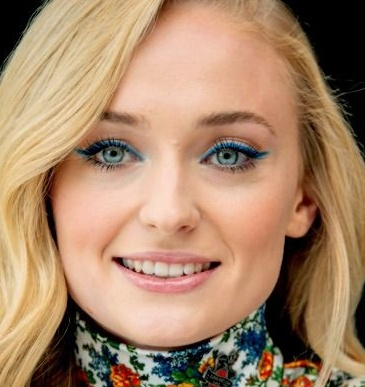

In [20]:
Image.open(df_pairs.iloc[0]["image1_path"])

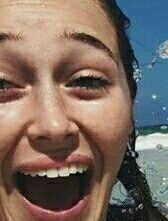

In [21]:
Image.open(df_pairs.iloc[0]["image2_path"])


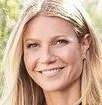

In [22]:
Image.open(df_pairs.iloc[4]["image1_path"])

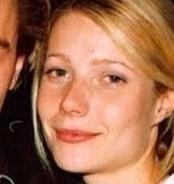

In [23]:
Image.open(df_pairs.iloc[4]["image2_path"])


In [24]:
os.makedirs(target_path, exist_ok=True)

In [25]:
%%time
for i in tqdm(range(0, 1000)):
    img1_target = f"{target_path}/{i}_1.jpg"
    img2_target = f"{target_path}/{i}_2.jpg"

    img1_path = df_pairs.iloc[i]["image1_path"]
    img2_path = df_pairs.iloc[i]["image2_path"]
    
    if os.path.exists(img1_target) is False:
        img1 = detect_and_align(img1_path)
        plt.imsave(img1_target, img1) #works for my debian
    
    if os.path.exists(img2_target) is False:
        img2 = detect_and_align(img2_path)
        plt.imsave(img2_target, img2) #works for my debian

100%|██████████| 1000/1000 [02:35<00:00,  6.44it/s]

CPU times: user 5min 58s, sys: 2.5 s, total: 6min
Wall time: 2min 35s


## Find Embeddings

In [26]:
def find_embeddings(img_path: str) -> List[list]:
    """
    Find embeddings of each face appearing in a given image
    Args:
        img_path (str): given input image
    Returns:
        results (list): embedding of each face
    """
    if os.path.exists(img_path) is False:
        raise ValueError(f"{img_path} not found")
    
    instances = []
    img_objs = DeepFace.represent(
        img_path = img_path,
        model_name = model_name,
        detector_backend = detector_backend,
        enforce_detection = False,
    )

    for img_obj in img_objs:
        embedding = img_obj["embedding"]
        instances.append(embedding)
    
    return instances

In [27]:
img_paths = []
for dirpath, dirnames, filenames in os.walk(target_path):
    for filename in filenames:
        img_path = f"{dirpath}/{filename}"
        img_paths.append(img_path)

In [28]:
print(f"there are {len(img_paths)} images available")

there are 2000 images available


In [29]:
%%time
embeddings_file = f"embeddings_{model_name}_{detector_backend}.pkl"

if os.path.exists(embeddings_file) is False:
    instances = []
    for img_path in tqdm(img_paths):
        embeddings = find_embeddings(img_path)
        for embedding in embeddings:
            instances.append((img_path, embedding))

    with open(embeddings_file, 'wb') as file:
        pickle.dump(instances, file)
else:
    print("embeddings calculated already")
    with open(embeddings_file, 'rb') as file:
        instances = pickle.load(file)

  0%|          | 0/2000 [00:00<?, ?it/s]2026-04-17 08:43:26.728334: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


26-04-17 08:43:29 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /root/.deepface/weights/facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /root/.deepface/weights/facenet512_weights.h5

  0%|          | 0.00/95.0M [00:00<?, ?B/s]
 12%|█▏        | 11.0M/95.0M [00:00<00:01, 80.7MB/s]
 20%|██        | 19.4M/95.0M [00:00<00:01, 45.7MB/s]
 27%|██▋       | 25.2M/95.0M [00:00<00:01, 41.6MB/s]
 34%|███▎      | 32.0M/95.0M [00:00<00:01, 36.8MB/s]
 45%|████▍     | 42.5M/95.0M [00:00<00:01, 42.4MB/s]
 56%|█████▌    | 53.0M/95.0M [00:01<00:00, 54.5MB/s]
 67%|██████▋   | 63.4M/95.0M [00:01<00:00, 64.2MB/s]
 78%|███████▊  | 73.9M/95.0M [00:01<00:00, 73.7MB/s]
 87%|████████▋ | 82.3M/95.0M [00:01<00:00, 64.5MB/s]
100%|██████████| 95.0M/95.0M [00:02<00:00, 44.5MB/s]
100%|██████████| 2000/2000 [17:27<00:00,  1.91it/s]

CPU times: user 23min 30s, sys: 1min 6s, total: 24min 36s
Wall time: 17min 27s


In [30]:
# while calculating distance in euclidean, squared values calculated, so negative values are not a problem
# but negative values in embeddings confuse the homomorphic encryption, apply min max normalization
if distance_metric == "cosine":
    min_val = np.inf
    max_val = -np.inf
    for img_path, embedding in instances:
        for i in embedding:
            if i < min_val:
                min_val = i
            if i > max_val:
                max_val = i

    print(f"min: {min_val}, max: {max_val}")

    for img_path, embedding in instances:
        for i in range(len(embedding)):
            embedding[i] = ( (np.array(embedding[i]) - min_val) / (max_val - min_val) ).tolist()

min: -4.414516448974609, max: 4.606593132019043


In [31]:
# normalize vectors in advance for cosine similarity
norm_instances = []
if distance_metric == "cosine":
    for img_path, embedding in instances:
        norm = np.linalg.norm(embedding)
        norm_instances.append((img_path, embedding / norm))
    instances = norm_instances

## Performance On Plain Embeddings

In [32]:
columns = ["img_path", "embedding"]

df = pd.DataFrame(instances, columns = columns)

In [33]:
df.head()

,img_path,embedding
0,/kaggle/working/PFR/test/941_1.jpg,"[0.04220882994672532, 0.04066307733525156, 0.0..."
1,/kaggle/working/PFR/test/157_1.jpg,"[0.03852019850007006, 0.03386483364544858, 0.0..."
2,/kaggle/working/PFR/test/359_1.jpg,"[0.03870173003115829, 0.04409795433463312, 0.0..."
3,/kaggle/working/PFR/test/404_1.jpg,"[0.03346223846496058, 0.039687239042215106, 0...."
4,/kaggle/working/PFR/test/989_2.jpg,"[0.04764660676313269, 0.050380421719859986, 0...."


In [34]:
def find_euclidean_distance(
    source_representation: list, test_representation: list
) -> np.float64:
    """
    Find Euclidean distance between two vectors or batches of vectors.

    Args:
        source_representation (list): 1st vector or batch of vectors.
        test_representation (list): 2nd vector or batch of vectors.

    Returns:
        np.float64: Euclidean distance(s).
            Returns a np.float64 for single embeddings and np.ndarray for batch embeddings.
    """
    source_representation = np.asarray(source_representation)
    test_representation = np.asarray(test_representation)

    euclidean_distance = source_representation - test_representation
    euclidean_distance = np.sum(np.multiply(euclidean_distance, euclidean_distance))
    euclidean_distance = np.sqrt(euclidean_distance)

    return euclidean_distance

def find_cosine_distance(
    source_representation: list, test_representation: list
) -> np.float64:
    # Convert lists to numpy arrays for efficient computation
    source_vector = np.array(source_representation)
    test_vector = np.array(test_representation)
    
    # Compute the dot product
    dot_product = np.dot(source_vector, test_vector)
    
    # Compute the norms (magnitudes) of the vectors
    norm_source = np.linalg.norm(source_vector)
    norm_test = np.linalg.norm(test_vector)
    
    # Compute cosine similarity
    cosine_similarity = dot_product / (norm_source * norm_test)
    
    # Compute cosine distance
    cosine_distance = 1 - cosine_similarity
    return cosine_distance

def norm(x: list) -> np.ndarray:
    """
    Normalize input vector with l2
    Args:
        x (np.ndarray or list): given vector
    Returns:
        y (np.ndarray): l2 normalized vector
    """
    # x = np.array(x)
    # return x / np.sqrt(np.sum(np.multiply(x, x)))
    return np.linalg.norm(x)

In [35]:
target_path

'/kaggle/working/PFR/test'

In [36]:
df[df["img_path"] == f"/kaggle/working/PFR/test/{282}_2.jpg"]["embedding"].values

array([array([0.04420335, 0.06497238, 0.03439109, 0.01805741, 0.04486498,
              0.03374279, 0.03681749, 0.05307736, 0.05061725, 0.06004533,
              0.03154236, 0.03984765, 0.03304858, 0.03175315, 0.03027875,
              0.03747755, 0.03965833, 0.0227575 , 0.05208836, 0.02961933,
              0.05494864, 0.05890394, 0.04402034, 0.04679173, 0.05584701,
              0.04907238, 0.04691068, 0.04016521, 0.04282535, 0.04763749,
              0.03049704, 0.04423464, 0.0563593 , 0.04165621, 0.05729226,
              0.04597888, 0.04705255, 0.04735289, 0.05288362, 0.02724534,
              0.03657888, 0.0358907 , 0.04596438, 0.06312739, 0.02174893,
              0.04509333, 0.02515012, 0.03350482, 0.03851595, 0.0500953 ,
              0.05381522, 0.01812744, 0.02486274, 0.02189657, 0.04519814,
              0.06980071, 0.03456914, 0.04720997, 0.04036748, 0.03235714,
              0.03652469, 0.06289805, 0.01758815, 0.03855418, 0.03340173,
              0.02910424, 0.03673741, 

In [37]:
pivot_distances = []
for i in tqdm(range(0, 1000)):
    img1_target = target_path +  f"/{i}_1.jpg"
    img2_target = target_path + f"/{i}_2.jpg"

    # print(i, ": -"*10)
    alphas = df[df["img_path"] == img1_target]["embedding"].values
    betas = df[df["img_path"] == img2_target]["embedding"].values
    # print(betas)
    
    # print("length of alphas: ",len(alphas))
    # print("length of betas: ",len(betas))
    distances = []
    for alpha in alphas:
        # print(i, alpha)
        for beta in betas:
            # print(i, beta)
            if distance_metric == "euclidean":
                distance = find_euclidean_distance(alpha, beta)
            else:
                distance = find_cosine_distance(alpha, beta)
                # print("Distance", distance)
            distances.append(distance)

    # print(len(distances))
    distance = min(distances)
    pivot_distances.append(distance)



100%|██████████| 1000/1000 [00:00<00:00, 1516.96it/s]


In [38]:
pivot = pd.DataFrame(pivot_distances, columns = ["distance"])
pivot["actual"] = df_pairs["is_same_person"].copy()

pivot["prediction"] = 0
tic = time.time()
idx = pivot[pivot["distance"] < threshold].index
pivot.loc[idx, "prediction"] = 1
toc = time.time()

In [39]:
pivot.head()

,distance,actual,prediction
0,0.039558,0,0
1,0.023589,1,1
2,0.038204,0,0
3,0.055997,0,0
4,0.031862,1,0


## Helper functions

In [40]:
def cal_metrics(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Confusion Matrix:\n", cm)
    
    # Full report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [41]:
def viz_cm(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm, cmap = 'coolwarm')
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    classes = ["Different", "Same"]
    tick_marks = np.arange(len(classes))
    
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    
    # show numbers
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [42]:


def viz_roc(df):
    y_true = df["actual"]
    y_pred = df["prediction"]
    
    y_scores = -df["distance"]  # smaller distance = more similar

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    
    plt.xlabel("False Positive Rate (FAR)")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    



In [43]:
cal_metrics(pivot)

Accuracy: 0.905
Precision: 0.9903147699757869
Recall: 0.818
F1-score: 0.895947426067908
Confusion Matrix:
 [[496   4]
 [ 91 409]]

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       500
           1       0.99      0.82      0.90       500

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.90      1000
weighted avg       0.92      0.91      0.90      1000



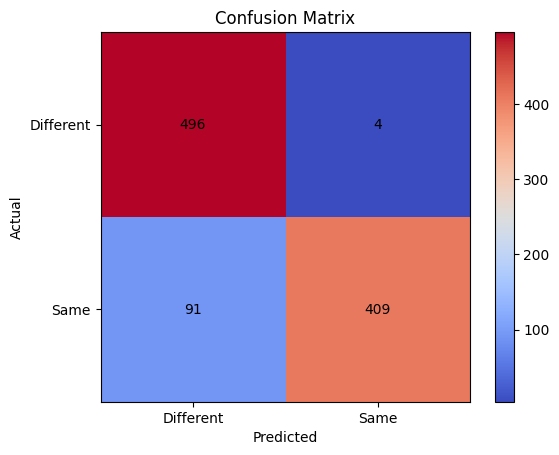

In [44]:
viz_cm(pivot)

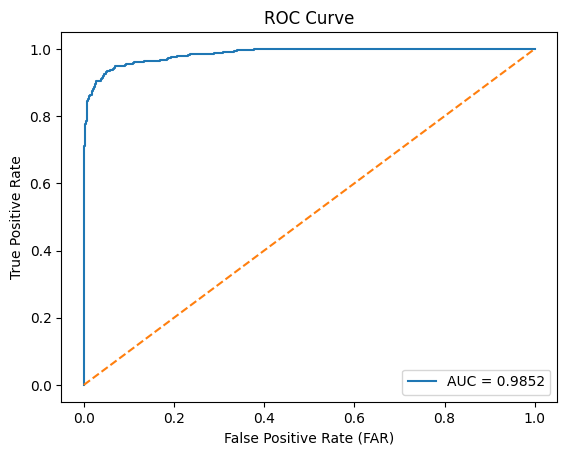

In [45]:
viz_roc(pivot)

In [46]:
# to find the best threshold
if True:
    tmp_df = pivot[["distance", "actual"]].copy()
    idx = tmp_df[tmp_df["actual"] == 1].index
    tmp_df["Decision"] = "Different Persons"
    tmp_df.loc[idx, "Decision"] = "Same Person"
    tmp_df = tmp_df.drop(columns = ["actual"])

    from chefboost import Chefboost
    chef_model = Chefboost.fit(tmp_df)
    print(chef_model["trees"])



26-04-17 09:01:02 - ID3 tree is going to be built...
26-04-17 09:01:03 - -------------------------
26-04-17 09:01:03 - finished in 0.8405349254608154 seconds
26-04-17 09:01:03 - -------------------------
26-04-17 09:01:03 - Evaluate train set
26-04-17 09:01:03 - -------------------------
26-04-17 09:01:03 - Accuracy: 93.8% on 1000 instances
26-04-17 09:01:03 - Labels: ['Different Persons' 'Same Person']
26-04-17 09:01:03 - Confusion matrix: [[471, 33], [29, 467]]
26-04-17 09:01:03 - Precision: 93.4524%, Recall: 94.2%, F1: 93.8247%
[<module 'outputs.rules.rules' from '/kaggle/working/outputs/rules/rules.py'>]


In [47]:
print(f"verification requires an additional {toc - tic} seconds")

verification requires an additional 0.0014719963073730469 seconds


<Axes: ylabel='Density'>

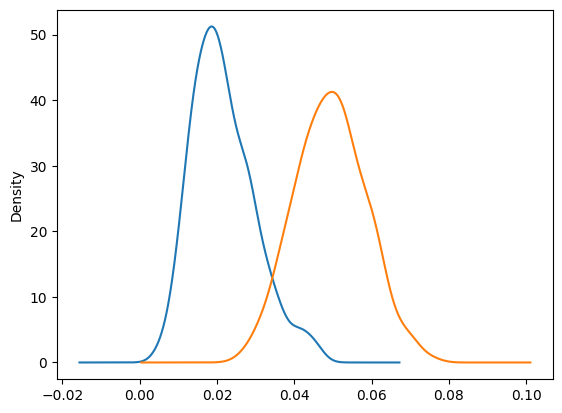

In [48]:
pivot[pivot.actual == 1].distance.plot.kde()
pivot[pivot.actual == 0].distance.plot.kde()

In [49]:
accuracy = 100 * len(pivot[pivot["actual"] == pivot["prediction"]]) / 1000
accuracy

90.5

### Initialize Homomorphic Enryption Object

In [50]:
def write_data(file_name, data):
    if type(data) == bytes:
        #bytes to base64
        data = base64.b64encode(data)
        
    with open(file_name, 'wb') as f: 
        f.write(data)

def read_data(file_name):
    with open(file_name, "rb") as f:
        data = f.read()
    
    #base64 to bytes
    return base64.b64decode(data)

In [51]:
mod, coeff, scale = cs_config
context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree = mod,
            coeff_mod_bit_sizes = coeff
          )
context.generate_galois_keys()
context.global_scale = 2**scale

secret_context = context.serialize(save_secret_key = True)
write_data("secret.txt", secret_context)

context.make_context_public() #drop the secret_key from the context
public_context = context.serialize()
write_data("public.txt", public_context)

del context, secret_context, public_context

# Encryption

In [52]:
context = ts.context_from(read_data("secret.txt"))

In [53]:
encrypted_embeddings = []

start_time = time.time()

for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
    img_path = instance["img_path"]

    embedding = instance["embedding"]
    enc_v1 = ts.ckks_vector(context, embedding)
    encrypted_embedding = enc_v1.serialize()
    encrypted_embeddings.append(encrypted_embedding)

end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / df.shape[0]  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")

100%|██████████| 2004/2004 [00:48<00:00, 41.73it/s]

Total time: 48.0280 s
ms/it: 23.9661


In [54]:
encrypted_df = df.copy()
encrypted_df = encrypted_df.drop(columns = ["embedding"])
encrypted_df["encrypted_embedding"] = encrypted_embeddings

In [55]:
encrypted_df.head()

,img_path,encrypted_embedding
0,/kaggle/working/PFR/test/941_1.jpg,b'\n\x02\x80\x04\x12\xa3\xdeh^\xa1\x10\x04\x01...
1,/kaggle/working/PFR/test/157_1.jpg,b'\n\x02\x80\x04\x12\xab\xdeh^\xa1\x10\x04\x01...
2,/kaggle/working/PFR/test/359_1.jpg,b'\n\x02\x80\x04\x12\x8c\xdeh^\xa1\x10\x04\x01...
3,/kaggle/working/PFR/test/404_1.jpg,b'\n\x02\x80\x04\x12\x91\xddh^\xa1\x10\x04\x01...
4,/kaggle/working/PFR/test/989_2.jpg,b'\n\x02\x80\x04\x12\xc8\xdch^\xa1\x10\x04\x01...


In [56]:
del context, enc_v1, encrypted_embedding

# Homomorphic Calculations

In [57]:
context = ts.context_from(read_data("public.txt"))

In [58]:
one = ts.ckks_vector(context, [1])
one.link_context(context)

In [59]:
calculations = []

start_time = time.time()

for i in tqdm(range(0, 1000)):
    img1_target = target_path +  f"/{i}_1.jpg"
    img2_target = target_path + f"/{i}_2.jpg"

    alphas_idxs = encrypted_df[encrypted_df["img_path"] == img1_target].index
    betas_idxs = encrypted_df[encrypted_df["img_path"] == img2_target].index

    encrypted_distances = []
    encrypted_distance_denominators = []
    for alphas_idx in alphas_idxs:
        alpha_proto = encrypted_df.loc[alphas_idx]["encrypted_embedding"]
        alpha = ts.lazy_ckks_vector_from(alpha_proto)
        alpha.link_context(context)

        for betas_idx in betas_idxs:
            beta_proto = encrypted_df.loc[betas_idx]["encrypted_embedding"]
            beta = ts.lazy_ckks_vector_from(beta_proto)
            beta.link_context(context)
            
            if distance_metric == "euclidean":
                difference = alpha - beta
                encrypted_distance = difference.dot(difference)

                # if you try to decrypt it here, you will get exception because you don't have the private key
                # encrypted_squared_distance.decrypt()

            else:
                encrypted_distance = one - alpha.dot(beta)
            
            encrypted_distance = encrypted_distance.serialize()
            encrypted_distances.append(encrypted_distance)

    calculations.append((img1_target, img2_target, encrypted_distances))

end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / 1000  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")

100%|██████████| 1000/1000 [02:59<00:00,  5.58it/s]

Total time: 179.3466 s
ms/it: 179.3466


In [60]:
del context, alpha_proto, beta_proto, alpha, beta

# Decryption

In [61]:
context = ts.context_from(read_data("secret.txt"))

In [62]:
distances = []

start_time = time.time()

for img1_path, img2_path, encrypted_distances in tqdm(calculations):

    current_distances = []
    for encrypted_distance_proto in encrypted_distances:
        encrypted_distance = ts.lazy_ckks_vector_from(encrypted_distance_proto)
        encrypted_distance.link_context(context)

        distance = encrypted_distance.decrypt()[0]

        current_distances.append(distance)
    
    distances.append(min(current_distances))


end_time = time.time()

# compute ms/it
total_time = end_time - start_time  # seconds
ms_per_it = 1000 * (total_time) / len(calculations)  # milliseconds per iteration

print(f"Total time: {total_time:.4f} s")
print(f"ms/it: {ms_per_it:.4f}")


100%|██████████| 1000/1000 [00:09<00:00, 104.06it/s]

Total time: 9.6140 s
ms/it: 9.6140


In [63]:
# results_df = pd.DataFrame(df_pairs[["is_same_person"]].copy(), columns = ["actual"])
results_df = pd.DataFrame({
    "actual": df_pairs["is_same_person"].values
})
results_df["distance"] = distances
if distance_metric == "euclidean":
    results_df["threshold"] = threshold * threshold
else:
    results_df["threshold"] = threshold

results_df["prediction"] = 0
tic = time.time()
idx = results_df[results_df["distance"] <= results_df["threshold"]].index
results_df.loc[idx, "prediction"] = 1
toc = time.time()

In [64]:
print(f"verification requires an additional {toc - tic} seconds")

verification requires an additional 0.0011708736419677734 seconds


In [65]:
results_df.head()

,actual,distance,threshold,prediction
0,0,0.045949,0.028745,0
1,1,0.029627,0.028745,0
2,0,0.044997,0.028745,0
3,0,0.063004,0.028745,0
4,1,0.038616,0.028745,0


In [66]:
cal_metrics(results_df)

Accuracy: 0.794
Precision: 1.0
Recall: 0.588
F1-score: 0.7405541561712846
Confusion Matrix:
 [[500   0]
 [206 294]]

Classification Report:

              precision    recall  f1-score   support

           0       0.71      1.00      0.83       500
           1       1.00      0.59      0.74       500

    accuracy                           0.79      1000
   macro avg       0.85      0.79      0.78      1000
weighted avg       0.85      0.79      0.78      1000



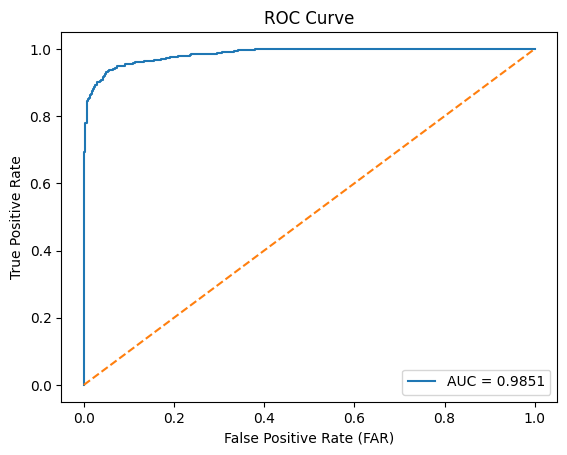

In [67]:
viz_roc(results_df)

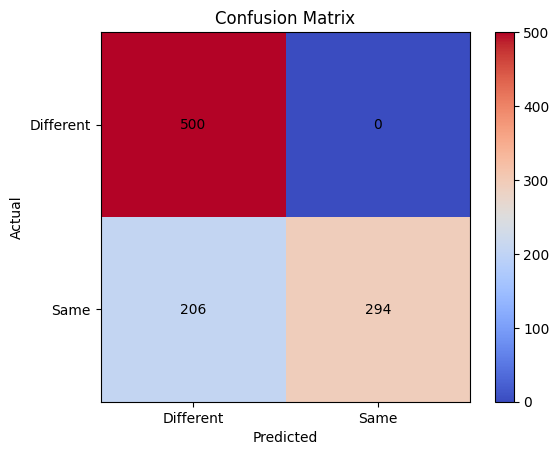

In [68]:
viz_cm(results_df)

In [69]:
homomorphic_accuracy = (100 * len(results_df[results_df["actual"] == results_df["prediction"]]) / 1000)
print(f"accuracy was {accuracy} in plain verification whereas it is {homomorphic_accuracy}")

accuracy was 90.5 in plain verification whereas it is 79.4
